# Практическое задание №3. Классификация мест залежей нефти и газа

## Загрузка данных, бибилиотек и первичный анализ данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
train = pd.read_csv('data/train_oil.csv')
test = pd.read_csv('data/oil_test.csv')

print(f"Размер train: {train.shape}")
print(f"Размер test: {test.shape}")

train.head()

Размер train: (309, 20)
Размер test: (133, 19)


,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
0,ZHIRNOV,MELEKESKIAN,RUSSIA,FORMER SOVIET UNION,VOLGA-URAL,COMPRESSION/EVAPORITE,51.0000,44.8042,NIZHNEVOLZHSKNET,ONSHORE,OIL,DECLINING PRODUCTION,FORELAND,1870,CARBONIFEROUS,SANDSTONE,262.0,33.0,24.0,30.0
1,LAGOA PARDA,LAGOA PARDA (URUCUTUCA),BRAZIL,LATIN AMERICA,ESPIRITO SANTO,EXTENSION,-19.6017,-39.8332,PETROBRAS,ONSHORE,OIL,NEARLY DEPLETED,PASSIVE MARGIN,4843,PALEOGENE,SANDSTONE,2133.0,72.0,23.0,350.0
2,ABQAIQ,ARAB D,SAUDI ARABIA,MIDDLE EAST,THE GULF,COMPRESSION/EVAPORITE,26.0800,49.8100,SAUDI ARAMCO,ONSHORE,OIL,REJUVENATING,FORELAND,6050,JURASSIC,LIMESTONE,250.0,184.0,21.0,410.0
3,MURCHISON,BRENT,UK /NORWAY,EUROPE,NORTH SEA NORTHERN,EXTENSION,61.3833,1.7500,CNR,OFFSHORE,OIL,NEARLY DEPLETED,RIFT,8988,JURASSIC,SANDSTONE,425.0,300.0,22.0,750.0
4,WEST PEMBINA,NISKU (PEMBINA L POOL),CANADA,NORTH AMERICA,WESTERN CANADA,COMPRESSION,53.2287,-115.8008,NUMEROUS,ONSHORE,OIL,UNKNOWN,FORELAND,9306,DEVONIAN,DOLOMITE,233.0,167.0,11.8,1407.0


Видно что в тестовой выборке нет целевой переменной - все правильно

In [3]:
test.head()

,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
0,ABU GHARADIG,BAHARIYA,EGYPT,AFRICA,ABU GHARADIG,EXTENSION,29.7422,28.4925,GUPCO,GAS-CONDENSATE,MATURE PRODUCTION,RIFT,10282,CRETACEOUS,SANDSTONE,745.0,144.0,10.0,8.0
1,ABU MADI-EL QARA,ABU MADI (LEVEL III),EGYPT,AFRICA,NILE DELTA,STRIKE-SLIP/TRANSTENSION/SHALE/EVAPORITE/BASEM...,31.4382,31.3616,IEOC,GAS,DECLINING PRODUCTION,WRENCH/DELTA,10499,NEOGENE,SANDSTONE,509.0,410.0,20.0,300.0
2,ALIBEKMOLA,KT I,KAZAKHSTAN,FORMER SOVIET UNION,CASPIAN NORTH,COMPRESSION/EVAPORITE,48.4740,57.6667,KAZAKHOIL AKTOBE,OIL,DEVELOPING,SUB-SALT/FORELAND,6000,CARBONIFEROUS,LIMESTONE,300.0,105.0,10.0,20.0
3,ALWYN NORTH,BRENT (BRENT EAST),UK,EUROPE,NORTH SEA NORTHERN,INVERSION/COMPRESSION/EXTENSION,60.7833,1.7333,TOTAL,OIL,NEARLY DEPLETED,RIFT,9790,JURASSIC,SANDSTONE,886.0,344.0,17.0,500.0
4,ANKLESHWAR,ANKLESHWAR (HAZAD-ARDOL),INDIA,FAR EAST,CAMBAY,STRIKE-SLIP/TRANSPRESSION/BASEMENT-I,21.6000,72.9167,ONGC,OIL,MATURE PRODUCTION,WRENCH/RIFT,2950,PALEOGENE,SANDSTONE,670.0,0.0,21.0,250.0


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Field name                      309 non-null    object 
 1   Reservoir unit                  309 non-null    object 
 2   Country                         282 non-null    object 
 3   Region                          271 non-null    object 
 4   Basin name                      271 non-null    object 
 5   Tectonic regime                 309 non-null    object 
 6   Latitude                        282 non-null    float64
 7   Longitude                       279 non-null    float64
 8   Operator company                309 non-null    object 
 9   Onshore/Offshore                309 non-null    object 
 10  Hydrocarbon type                309 non-null    object 
 11  Reservoir status                309 non-null    object 
 12  Structural setting              309 

Данные и их типы выглядят корректно, но видно, что в данных есть пропуски

In [5]:
train.describe()

,Latitude,Longitude,Depth,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
count,282.00000,279.000000,309.000000,309.000000,309.000000,309.000000,309.000000
mean,35.62426,-12.508435,6755.669903,760.087379,183.683236,17.825178,476.994757
std,22.19116,86.387220,3628.094135,1353.934404,282.252489,7.171048,1000.140605
min,-38.39890,-151.615300,220.000000,11.000000,2.120000,1.100000,0.010000
25%,28.24915,-102.336500,4059.000000,128.000000,45.000000,12.000000,10.000000
50%,38.13500,1.810000,6500.000000,312.000000,110.000000,17.000000,68.000000
75%,52.13360,56.179900,9186.000000,715.000000,205.000000,23.600000,390.000000
max,76.44620,148.417000,19888.000000,8200.000000,2976.000000,35.000000,7500.000000


In [6]:
print(train.isnull().sum())

Field name                         0
Reservoir unit                     0
Country                           27
Region                            38
Basin name                        38
Tectonic regime                    0
Latitude                          27
Longitude                         30
Operator company                   0
Onshore/Offshore                   0
Hydrocarbon type                   0
Reservoir status                   0
Structural setting                 0
Depth                              0
Reservoir period                   0
Lithology                          0
Thickness (gross average ft)       0
Thickness (net pay average ft)     0
Porosity                           0
Permeability                       0
dtype: int64


Onshore/Offshore
ONSHORE             218
OFFSHORE             86
ONSHORE-OFFSHORE      5
Name: count, dtype: int64


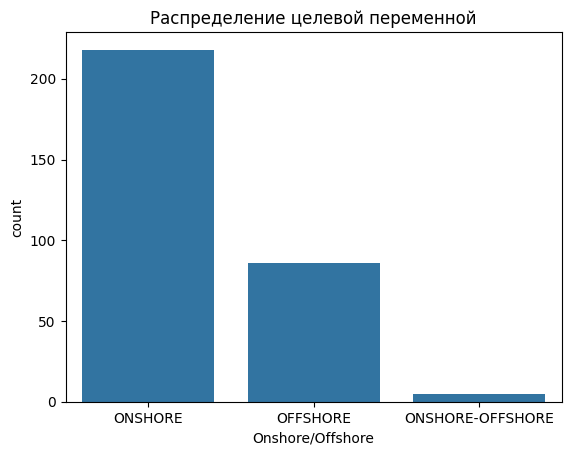

In [7]:
print(train['Onshore/Offshore'].value_counts())
sns.countplot(x='Onshore/Offshore', data=train)
plt.title('Распределение целевой переменной')
plt.show()

Из построенного распределения видно что переменная имее 3 класса среди которых наблюдается сильный дисбаланс, следовательно необзодимо предобработать категориальные признаки 

## Предобработка данных 

Сначала выделим признаки и целевую переменную

In [8]:
# Разделение на признаки и целевую переменную
X = train.drop(['Onshore/Offshore', 'Field name'], axis=1)
y = train['Onshore/Offshore']

le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

print("Соответствие текст → число:")
for i, name in enumerate(le_target.classes_):
    print(f"  {name} → {i}")

Соответствие текст → число:
  OFFSHORE → 0
  ONSHORE → 1
  ONSHORE-OFFSHORE → 2


Также подготовим тестовые данные

In [9]:
test_ids = test['Field name']
X_test = test.drop(['Field name'], axis=1)

Дальше необходимо выделить числовые и категориальные признаки, это важно потому что для разных типов данных нужны разные методы обработки

In [10]:
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"Числовые признаки: {numeric_cols}")
print(f"Категориальные признаки: {categorical_cols}")

Числовые признаки: ['Latitude', 'Longitude', 'Depth', 'Thickness (gross average ft)', 'Thickness (net pay average ft)', 'Porosity', 'Permeability']
Категориальные признаки: ['Reservoir unit', 'Country', 'Region', 'Basin name', 'Tectonic regime', 'Operator company', 'Hydrocarbon type', 'Reservoir status', 'Structural setting', 'Reservoir period', 'Lithology']


Заполним пропуски в числовых признаках на медианное значение, медиана лучше среднего так как она устойчива к выбросам

In [11]:
for col in numeric_cols:
    X[col] = X[col].fillna(X[col].median())
    X_test[col] = X_test[col].fillna(X[col].median())
    
print("Пропуски в числовых признаках заполнены медианой")

Пропуски в числовых признаках заполнены медианой


Далее перейдем к заполнению пропусков в категориальных признаках, их мы заполним модой

In [12]:
for col in categorical_cols:
    # Находим моду в тренировочных данных
    mode_value = X[col].mode()[0] if len(X[col].mode()) > 0 else 'Unknown'
    X[col] = X[col].fillna(mode_value)
    X_test[col] = X_test[col].fillna(mode_value)
    
print("Пропуски в категориальных признаках заполнены модой")

Пропуски в категориальных признаках заполнены модой


Далее выполним кодирование категориальных признаков, поскольку модели машинного обучения работают только с числовыми значениями

In [13]:
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    # Обучаем на тренировочных данных
    X[col] = le.fit_transform(X[col].astype(str))
    
    # Для тестовых данных: заменяем неизвестные значения на 'Unknown' и кодируем
    test_values = X_test[col].astype(str)
    known_values = set(le.classes_)
    
    # Создаем маску для новых значений
    mask = ~test_values.isin(known_values)
    test_values_processed = test_values.copy()
    test_values_processed[mask] = 'Unknown'
    
    # Добавляем 'Unknown' в encoder, если его еще нет
    if 'Unknown' not in le.classes_:
        le.classes_ = np.append(le.classes_, 'Unknown')
    
    # Трансформируем
    X_test[col] = le.transform(test_values_processed)
    label_encoders[col] = le

В тестовых значениях были обнаружены значения которых не было на тренировочных данных, их мы отнесли в отдельную категорию 'Unknown'

## Разделение на train/validation


In [14]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Train size: {X_train.shape}")
print(f"Val size: {X_val.shape}")

Train size: (247, 18)
Val size: (62, 18)


## Обучение нескольких моделей

In [15]:
from sklearn.metrics import f1_score

# Создание моделей
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(random_state=42)
}

# Обучение и оценка
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    
    # Считаем обе метрики
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    
    results[name] = {'accuracy': acc, 'f1_weighted': f1}
    
    print(f"{name}:")
    print(f"  Accuracy = {acc:.4f}")
    print(f"  F1-weighted = {f1:.4f}")
    print(classification_report(y_val, y_pred))
    print("-" * 50)

# Выбор лучшей модели по F1-weighted
best_model_name = max(results, key=lambda x: results[x]['f1_weighted'])
print(f"\n Лучшая модель по F1-weighted: {best_model_name} = {results[best_model_name]['f1_weighted']:.4f}")


Logistic Regression:
  Accuracy = 0.7742
  F1-weighted = 0.7553
              precision    recall  f1-score   support

           0       0.67      0.47      0.55        17
           1       0.80      0.91      0.85        44
           2       0.00      0.00      0.00         1

    accuracy                           0.77        62
   macro avg       0.49      0.46      0.47        62
weighted avg       0.75      0.77      0.76        62

--------------------------------------------------
Random Forest:
  Accuracy = 0.8548
  F1-weighted = 0.8476
              precision    recall  f1-score   support

           0       0.76      0.76      0.76        17
           1       0.89      0.91      0.90        44
           2       0.00      0.00      0.00         1

    accuracy                           0.85        62
   macro avg       0.55      0.56      0.55        62
weighted avg       0.84      0.85      0.85        62

--------------------------------------------------
Gradient Boost

В обучающей выборке наблюдается сильный дисбаланс:
- **ONSHORE** — 218 объектов (70.6%)
- **OFFSHORE** — 86 объектов (27.8%)
- **ONSHORE-OFFSHORE** — 5 объектов (1.6%)

Из-за этого все модели не смогли корректно предсказать редкий класс 2 (ONSHORE-OFFSHORE). На валидационной выборке этот класс представлен всего одним объектом, что делает его предсказание крайне сложным.

## Подбор гиперпараметров для лучшей модели

Для подбора гипер параметров используем GridSearchCV, так как количество комбинаций ограничено (162 варианта) и нет необходимости использовать случайный перебор.

In [16]:
rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 9, 10, 11, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    rf, param_grid, cv=5, scoring='f1_weighted', n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучшая кросс-валидация (F1-weighted): {grid_search.best_score_:.4f}")

best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_val)
print(f"F1-weighted на валидации: {f1_score(y_val, y_pred, average='weighted'):.4f}")

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Лучшие параметры: {'max_depth': 9, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Лучшая кросс-валидация (F1-weighted): 0.8737
F1-weighted на валидации: 0.8451


Видно что на валидаци F1 уменьщилась с 0.8737 до 0.8451. Разница составляет ~0.03 — незначительное снижение, переобучения нет.

# Важность признаков

Оценим, какие признаки больше всего влияют на предсказание модели

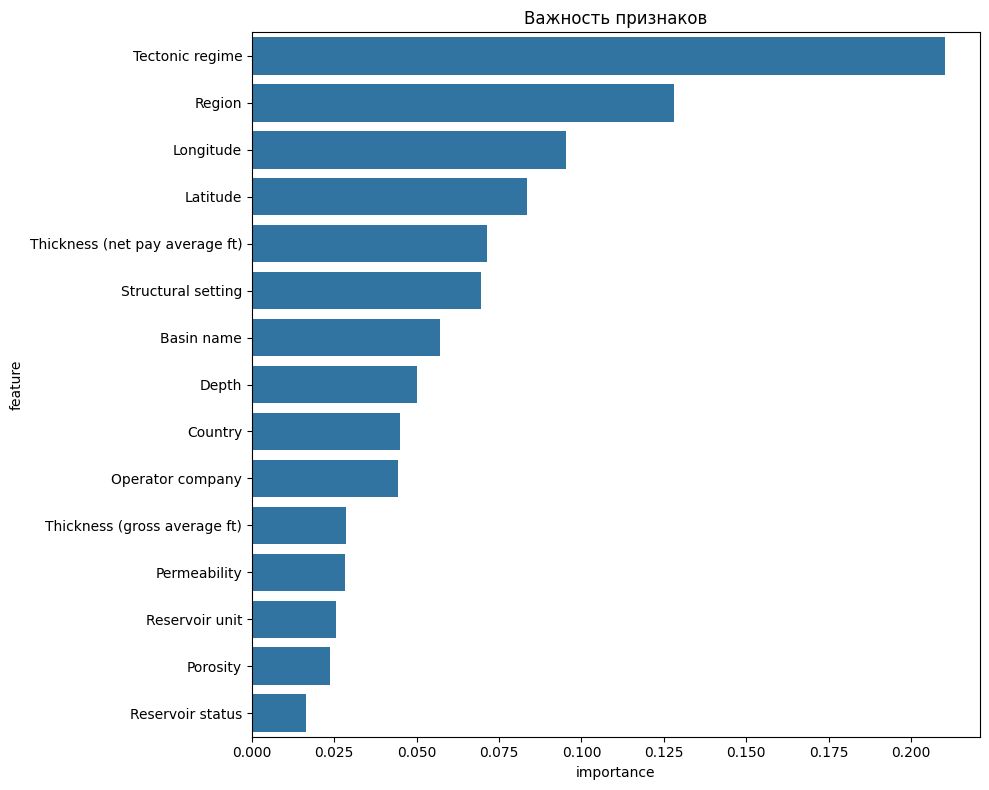

                           feature  importance
4                  Tectonic regime    0.210445
2                           Region    0.128040
6                        Longitude    0.095470
5                         Latitude    0.083603
15  Thickness (net pay average ft)    0.071492
10              Structural setting    0.069450
3                       Basin name    0.057228
11                           Depth    0.049994
1                          Country    0.044834
7                 Operator company    0.044207


In [17]:
# Визуализация важности признаков
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=feature_importance.head(15))
plt.title('Важность признаков')
plt.tight_layout()
plt.show()

print(feature_importance.head(10))

## Предсказание на тестовых данных

Сделаем предсказания и запишем результаты в файл

In [18]:
# Предсказание на тестовых данных
test_predictions = best_rf.predict(X_test)

# Создание файла для отправки на Kaggle
submission = pd.DataFrame({
    'index': range(len(test_predictions)),  # 0, 1, 2, ... до 132
    'Onshore/Offshore': test_predictions
})

submission.to_csv('submission.csv', index=False)
print("Файл submission.csv создан!")
display(submission)

Файл submission.csv создан!


,index,Onshore/Offshore
0,0,1
1,1,0
2,2,1
3,3,0
4,4,1
...,...,...
128,128,1
129,129,1
130,130,1
131,131,1


In [19]:
submission.shape

(133, 2)

In [20]:
submission['Onshore/Offshore'].dtype

dtype('int64')

## Результат

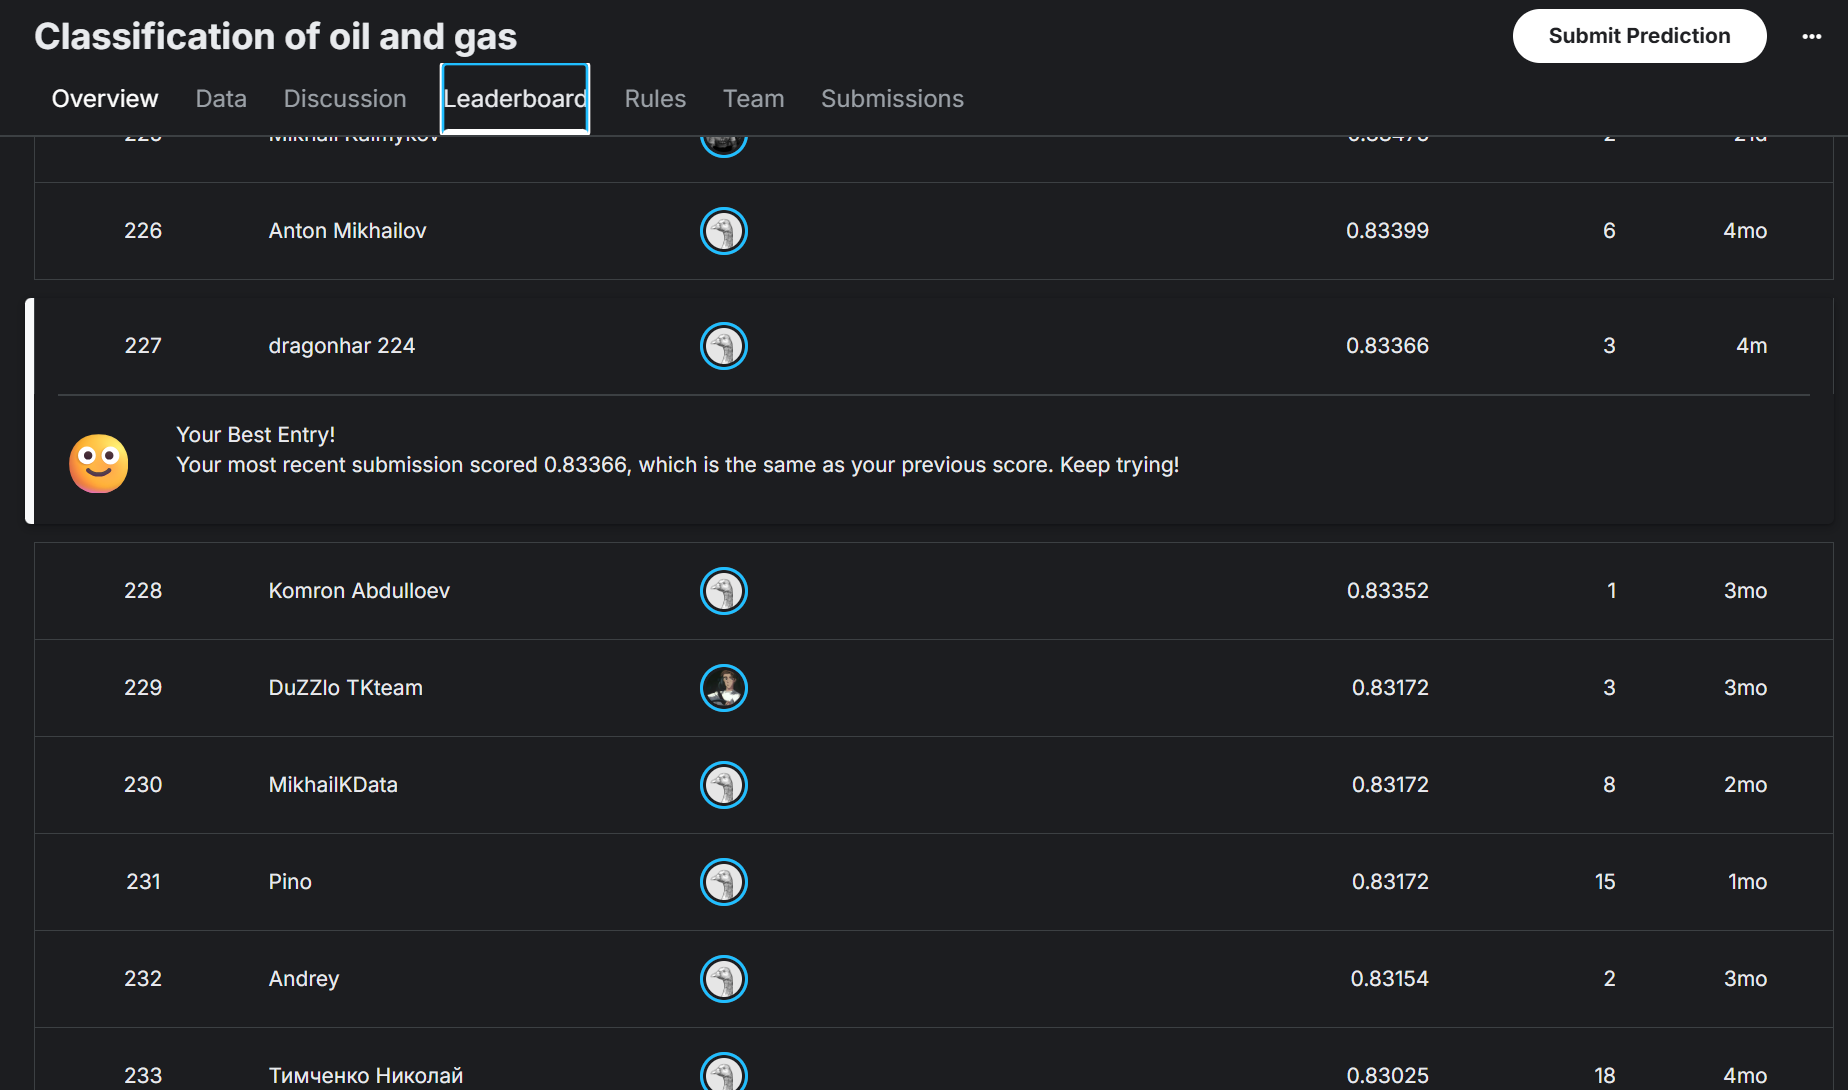

Результат на Kaggle: F1-score = 0.83366.  
Модель показала хороший результат, который можно улучшить за счет обработки дисбаланса классов.  